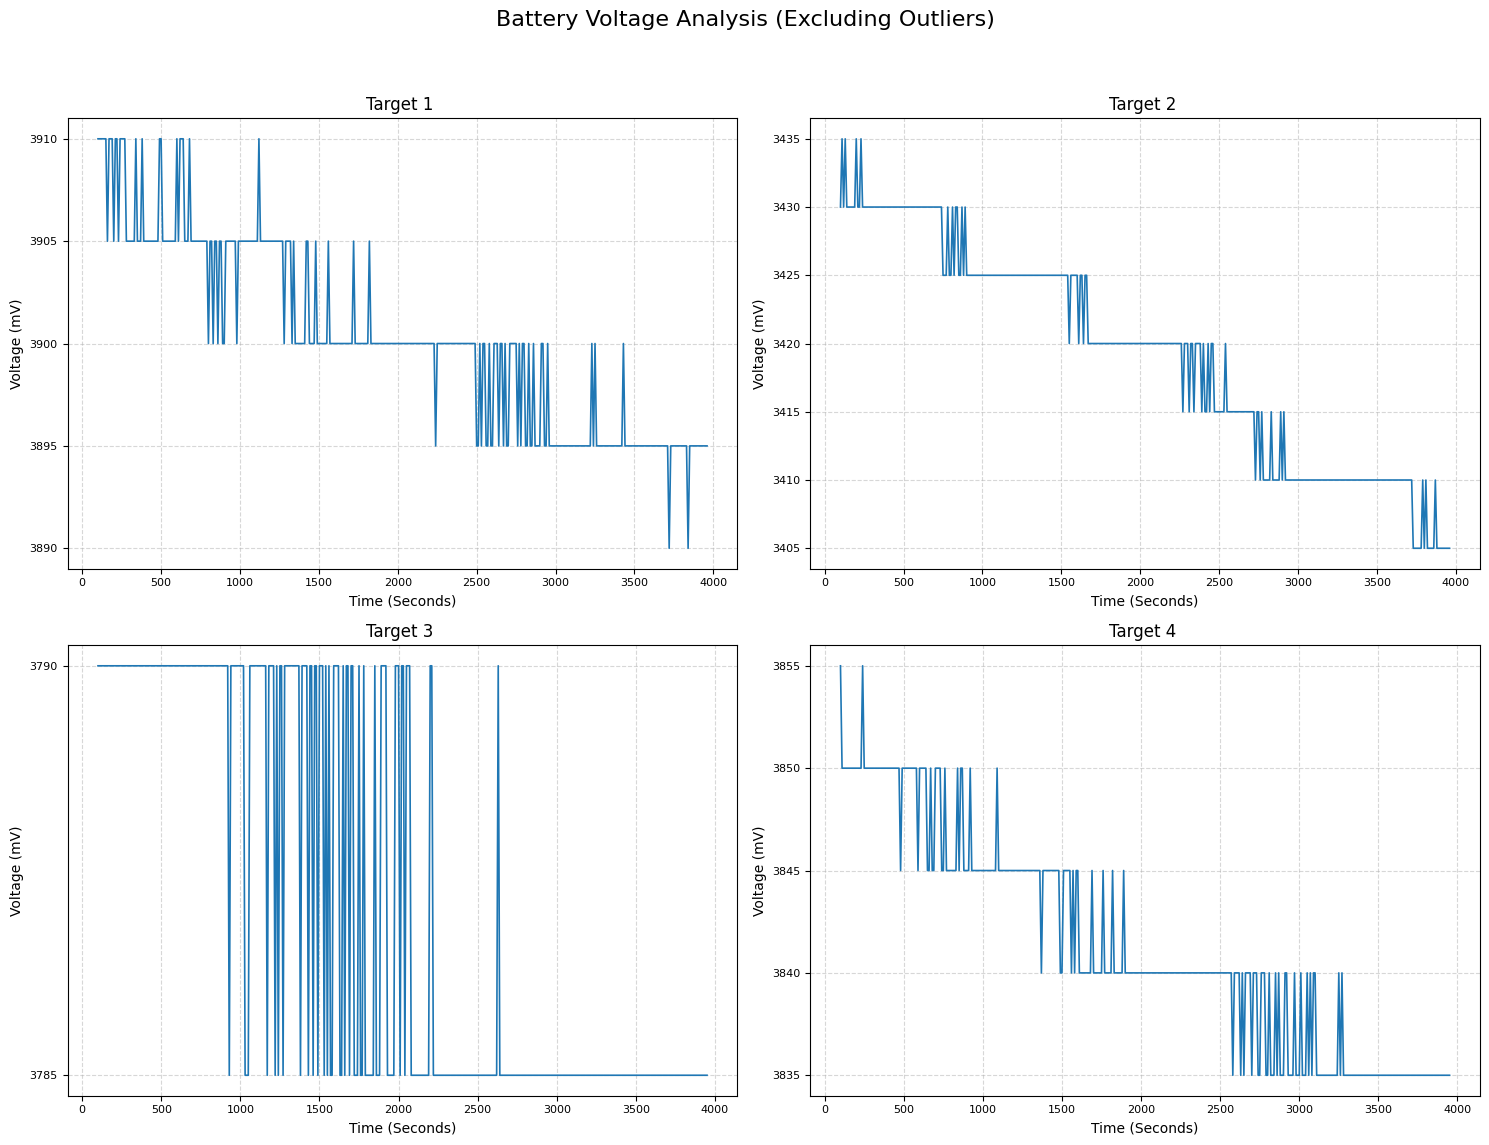

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# 1. 파일 경로 설정 (윈도우 경로 오류 방지를 위해 r을 붙임)
base_path = r"C:\Users\gmlwn\OneDrive\바탕 화면\ICon2학년\DLC_system_model"

file_names = [
    f"{base_path}\\1.csv",
    f"{base_path}\\2.csv",
    f"{base_path}\\3.csv",
    f"{base_path}\\4.csv"
]
# 2x2 서브플롯 생성 (가로 15, 세로 12 크기)
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for i, file in enumerate(file_names):
    ax = axes[i]
    try:
        # 데이터 로드 (헤더 포함 및 불량 라인 건너뛰기)
        df = pd.read_csv(file, header=0, on_bad_lines='skip')
        
        # 데이터 수치 변환 및 결측치 제거
        df['time_s'] = pd.to_numeric(df['time_s'], errors='coerce')
        df['vbat_mV'] = pd.to_numeric(df['vbat_mV'], errors='coerce')
        df = df.dropna(subset=['time_s', 'vbat_mV'])
        
        # 앞뒤 10개 데이터 제외 필터링
        if len(df) > 20:
            df_filtered = df.iloc[10:-10].copy()
        else:
            df_filtered = df.copy()
            
        if not df_filtered.empty:
            # 메인 그래프 그리기
            ax.plot(df_filtered['time_s'], df_filtered['vbat_mV'], color='tab:blue', linewidth=1.2)
            
            # Y축 눈금을 5단위로 설정
            ax.yaxis.set_major_locator(ticker.MultipleLocator(5))
            
            # 그래프 스타일 및 폰트 설정
            ax.set_title(f'Target {i+1} ', fontsize=12)
            ax.set_xlabel('Time (Seconds)', fontsize=10)
            ax.set_ylabel('Voltage (mV)', fontsize=10)
            ax.grid(True, linestyle='--', alpha=0.5)
            
            # 축 눈금(Tick) 폰트 크기 조절
            ax.tick_params(axis='both', labelsize=8)

    except Exception as e:
        ax.set_title(f'⚠️ Error in {file}')
        print(f"{file} 처리 중 오류 발생: {e}")

# 전체 통합 제목 설정
plt.suptitle('Battery Voltage Analysis (Excluding Outliers)', fontsize=16)

# 서브플롯 간 간격 및 상단 제목 공간 확보
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# 그래프 출력
plt.show()